# Cardiovascular Disease Risk Prediction — Complete EDA & Machine Learning

**Author:** Mobeen Fatima  
**Dataset:** Cardiovascular Disease Risk Prediction Dataset  
**Task:** Exploratory Data Analysis, statistical analysis, preprocessing, classification, model comparison, tuning, explainability, and final evaluation.

This notebook is designed to run directly on Kaggle after adding the dataset as an input. The dataset is synthetic and is intended for machine learning, analytics, and educational/research use rather than clinical diagnosis.

The notebook intentionally keeps a Markdown explanation immediately before every code cell so that the workflow is easy to follow and publish as a complete Kaggle notebook.

In [1]:
# Core imports and notebook configuration

import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RANDOM_STATE = 42

print("Python environment ready.")
print("Working directory:", os.getcwd())


Python environment ready.
Working directory: /kaggle/working


## 1. Locate the Kaggle dataset

Kaggle mounts attached datasets under `/kaggle/input`. Instead of hard-coding one filename, this cell searches the mounted input directories for CSV files. That makes the notebook more robust if the dataset filename changes slightly.

In [2]:
csv_files = glob.glob("/kaggle/input/**/*.csv", recursive=True)

if not csv_files:
    raise FileNotFoundError(
        "No CSV file was found under /kaggle/input. "
        "Add the Cardiovascular Disease Risk Prediction Dataset to this notebook."
    )

print(f"CSV files found: {len(csv_files)}")
for path in csv_files:
    print(" -", path)

# Prefer a file whose name contains heart/cardiovascular/risk-related terms.
preferred = [
    p for p in csv_files
    if any(term in os.path.basename(p).lower()
           for term in ["heart", "cardio", "cardiovascular", "risk"])
]

DATA_PATH = preferred[0] if preferred else csv_files[0]
print("\nSelected file:", DATA_PATH)


CSV files found: 2
 - /kaggle/input/datasets/mobeenfatimah/cardiovascular-disease-risk-prediction-dataset/data_dictionary.csv
 - /kaggle/input/datasets/mobeenfatimah/cardiovascular-disease-risk-prediction-dataset/cardiovascular_disease_prediction.csv

Selected file: /kaggle/input/datasets/mobeenfatimah/cardiovascular-disease-risk-prediction-dataset/cardiovascular_disease_prediction.csv


## 2. Load the data

The dataset is loaded into a pandas DataFrame. We also make a copy so the original loaded object remains available if later preprocessing changes the working data.

In [3]:
df = pd.read_csv(DATA_PATH)
data = df.copy()

print("Dataset loaded successfully.")
print("Shape:", data.shape)
display(data.head())


Dataset loaded successfully.
Shape: (20000, 35)


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Heart_Rate,Cholesterol,HDL,LDL,Triglycerides,Blood_Glucose,Diabetes,Hypertension,Smoking,Alcohol_Consumption,Physical_Activity,Exercise_Days_Per_Week,Daily_Walking_Minutes,Sleep_Hours,Stress_Level,Family_History,Chest_Pain,Shortness_of_Breath,ECG_Result,Medication,Diet_Quality,Annual_Income_USD,Region,Education_Level,BMI_Category,Risk_Score,Cardiovascular_Disease
0,110651,41,Female,165.600,89.000,32.500,118,79,85,248,44.000,NaN,255.000,93.000,No,No,Yes,No,Moderate,7,56,8.500,High,No,No,No,Normal,No,Average,109870,Central,Bachelor,Obese,7.630,0
1,102042,43,Female,163.100,40.000,15.000,114,55,73,219,58.000,96.000,176.000,75.000,No,No,No,No,Moderate,2,42,7.000,Low,No,No,Yes,Normal,No,Poor,33025,North,Master,Underweight,2.960,0
2,108669,37,Female,154.000,96.200,40.600,127,74,68,219,23.000,107.000,231.000,118.000,No,No,Yes,Yes,Low,5,82,7.700,Moderate,No,No,No,Normal,No,Poor,53705,South,Bachelor,Obese,9.730,0
3,101115,81,Female,168.700,72.800,25.600,137,87,70,154,49.000,102.000,207.000,NaN,Yes,No,Yes,No,Moderate,4,111,8.000,Moderate,Yes,Yes,Yes,Normal,Yes,Average,172645,West,Bachelor,Overweight,15.810,1
4,113903,32,Female,176.700,53.100,17.000,144,79,66,225,58.000,96.000,136.000,121.000,No,Yes,Yes,No,Moderate,5,56,6.500,Moderate,Yes,No,No,Normal,Yes,Average,93228,West,High School,Underweight,9.400,0


## 3. Dataset dimensions and column inventory

This section gives a first structural view of the dataset: number of observations, number of variables, and exact column names. Understanding the schema is important before any transformation or modeling.

In [4]:
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

print("\nColumns:")
for i, col in enumerate(data.columns, start=1):
    print(f"{i:02d}. {col}")


Number of rows: 20000
Number of columns: 35

Columns:
01. Patient_ID
02. Age
03. Gender
04. Height_cm
05. Weight_kg
06. BMI
07. Blood_Pressure_Systolic
08. Blood_Pressure_Diastolic
09. Heart_Rate
10. Cholesterol
11. HDL
12. LDL
13. Triglycerides
14. Blood_Glucose
15. Diabetes
16. Hypertension
17. Smoking
18. Alcohol_Consumption
19. Physical_Activity
20. Exercise_Days_Per_Week
21. Daily_Walking_Minutes
22. Sleep_Hours
23. Stress_Level
24. Family_History
25. Chest_Pain
26. Shortness_of_Breath
27. ECG_Result
28. Medication
29. Diet_Quality
30. Annual_Income_USD
31. Region
32. Education_Level
33. BMI_Category
34. Risk_Score
35. Cardiovascular_Disease


## 4. Data types and memory usage

We inspect data types and memory usage to identify numeric and categorical variables and to detect columns that may require conversion.

In [5]:
info = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "non_null": data.notna().sum(),
    "missing": data.isna().sum(),
    "unique": data.nunique(dropna=False),
    "memory_bytes": data.memory_usage(deep=True).reindex(data.columns)
})

display(info)
print("\nTotal memory used by columns:",
      f"{data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


,dtype,non_null,missing,unique,memory_bytes
Patient_ID,int64,20000,0,20000,160000
Age,int64,20000,0,66,160000
Gender,object,20000,0,2,1080890
Height_cm,float64,20000,0,532,160000
Weight_kg,float64,20000,0,762,160000
BMI,float64,19400,600,383,160000
Blood_Pressure_Systolic,int64,20000,0,102,160000
Blood_Pressure_Diastolic,int64,20000,0,72,160000
Heart_Rate,int64,20000,0,68,160000
Cholesterol,int64,20000,0,217,160000



Total memory used by columns: 19.13 MB


## 5. Missing-value audit

Missing values can affect both statistical analysis and machine learning. This audit reports missing counts and percentages for every feature.

In [6]:
missing = pd.DataFrame({
    "missing_count": data.isna().sum(),
    "missing_percent": data.isna().mean().mul(100)
}).sort_values("missing_count", ascending=False)

display(missing)

if missing["missing_count"].sum() == 0:
    print("No missing values were detected.")


,missing_count,missing_percent
Triglycerides,600,3.000
HDL,600,3.000
BMI,600,3.000
Physical_Activity,600,3.000
Blood_Glucose,600,3.000
Diet_Quality,600,3.000
LDL,600,3.000
Sleep_Hours,600,3.000
Gender,0,0.000
Patient_ID,0,0.000


## 6. Duplicate-record audit

Duplicate observations can distort distributions and model evaluation. We check the complete rows and report how many duplicates are present.

In [7]:
duplicate_count = data.duplicated().sum()
print("Duplicate rows:", duplicate_count)

if duplicate_count:
    display(data[data.duplicated(keep=False)].head(20))
else:
    print("No duplicate rows were detected.")


Duplicate rows: 0
No duplicate rows were detected.


## 7. Descriptive statistics for numeric features

The numerical summary includes central tendency, spread, and range. This helps identify unusually scaled variables and potential outliers before modeling.

In [8]:
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()

print("Numeric columns:", len(numeric_columns))
display(data[numeric_columns].describe().T)


Numeric columns: 19


,count,mean,std,min,25%,50%,75%,max
Patient_ID,"20,000.000","110,000.500","5,773.647","100,001.000","105,000.750","110,000.500","115,000.250","120,000.000"
Age,"20,000.000",52.527,19.056,20.000,36.000,52.000,69.000,85.000
Height_cm,"20,000.000",168.019,9.903,145.000,161.200,168.000,174.800,200.000
Weight_kg,"20,000.000",72.169,14.804,40.000,61.900,72.200,82.300,128.200
BMI,"19,400.000",25.835,6.148,10.200,21.500,25.500,29.800,56.500
Blood_Pressure_Systolic,"20,000.000",124.780,17.633,90.000,113.000,124.000,137.000,193.000
Blood_Pressure_Diastolic,"20,000.000",79.595,11.765,55.000,71.000,80.000,88.000,130.000
Heart_Rate,"20,000.000",74.495,9.980,45.000,68.000,75.000,81.000,112.000
Cholesterol,"20,000.000",204.891,39.528,120.000,177.000,204.000,232.000,350.000
HDL,"19,400.000",54.537,14.789,20.000,44.000,54.000,64.000,100.000


## 8. Descriptive statistics for categorical features

Categorical variables are summarized using frequency tables. This reveals the number of categories and the dominant levels in each categorical feature.

In [9]:
categorical_columns = data.select_dtypes(exclude=np.number).columns.tolist()

print("Categorical columns:", len(categorical_columns))
for col in categorical_columns:
    print(f"\n--- {col} ---")
    display(data[col].value_counts(dropna=False).to_frame("count").head(20))


Categorical columns: 16

--- Gender ---


,count
Gender,
Female,10445
Male,9555



--- Diabetes ---


,count
Diabetes,
No,13912
Yes,6088



--- Hypertension ---


...

,count
Region,
Central,4030
West,4005
East,4001
North,3998
South,3966



--- Education_Level ---


,count
Education_Level,
Bachelor,7947
High School,7041
Master,3989
PhD,1023



--- BMI_Category ---


,count
BMI_Category,
Normal,7102
Overweight,5886
Obese,4788
Underweight,2224


## 9. Detect the target variable

The dataset uses `Heart_Disease` as the prediction target. The cell verifies that the expected target exists and reports its unique values.

In [10]:
TARGET = "Cardiovascular_Disease"

if TARGET not in data.columns:
    raise KeyError(
        f"Expected target '{TARGET}' was not found. "
        f"Available columns: {data.columns.tolist()}"
    )

print("Target column:", TARGET)
print("Target dtype:", data[TARGET].dtype)
print("Target values:", sorted(data[TARGET].dropna().unique().tolist()))

Target column: Cardiovascular_Disease
Target dtype: int64
Target values: [0, 1]


## 10. Target distribution

We examine the number and percentage of observations in each target class. This is important for understanding class balance and choosing suitable evaluation metrics.

,count,percentage
Cardiovascular_Disease,,
0,13880,69.400
1,6120,30.600


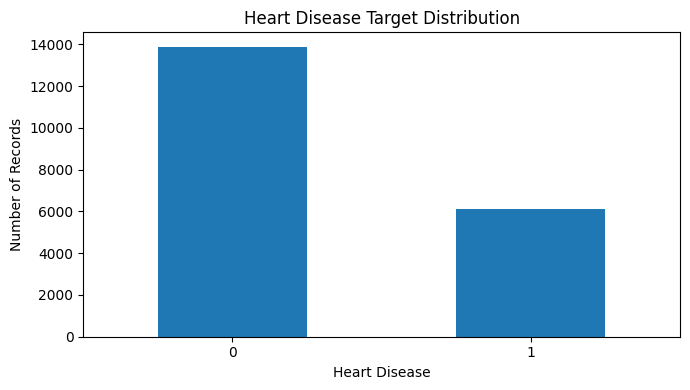

In [11]:
target_counts = data[TARGET].value_counts(dropna=False).sort_index()
target_percent = data[TARGET].value_counts(normalize=True, dropna=False).sort_index().mul(100)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percent
})

display(target_summary)

plt.figure(figsize=(7, 4))
target_counts.plot(kind="bar")
plt.title("Heart Disease Target Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 13. Categorical feature distributions

Bar charts for categorical variables help identify dominant groups and categories with very few observations.

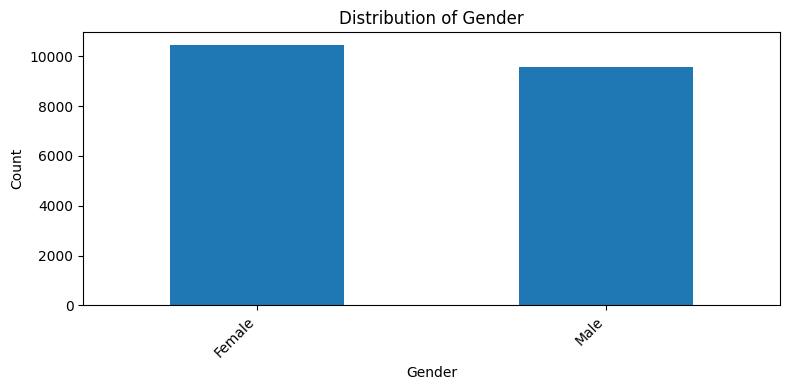

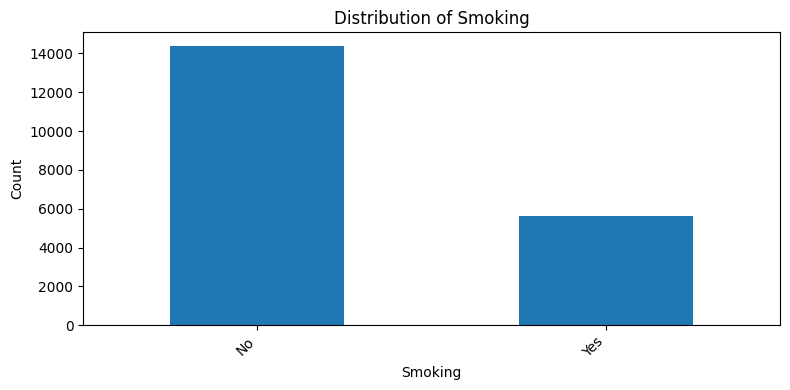

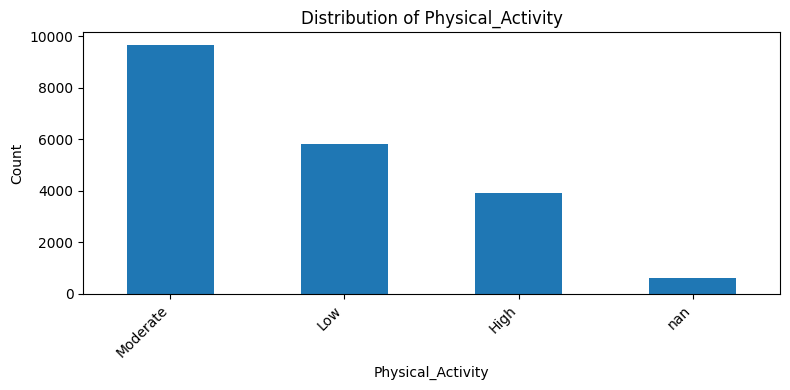

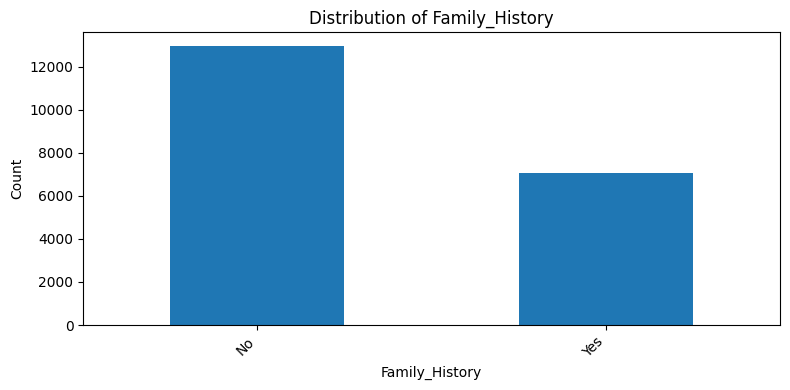

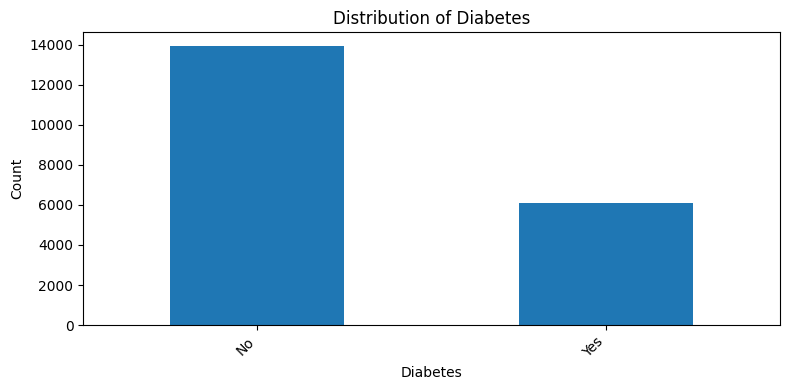

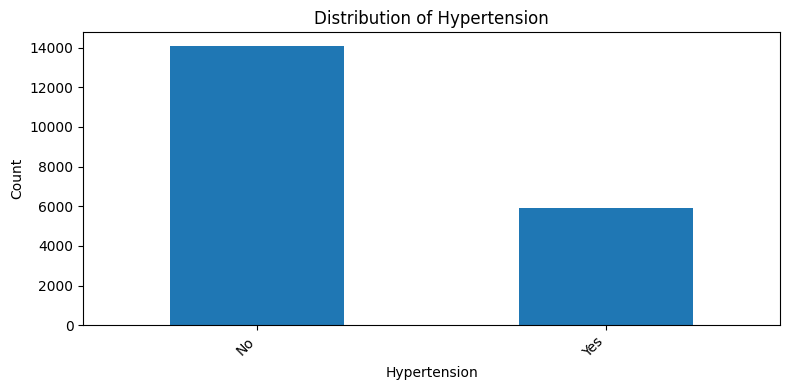

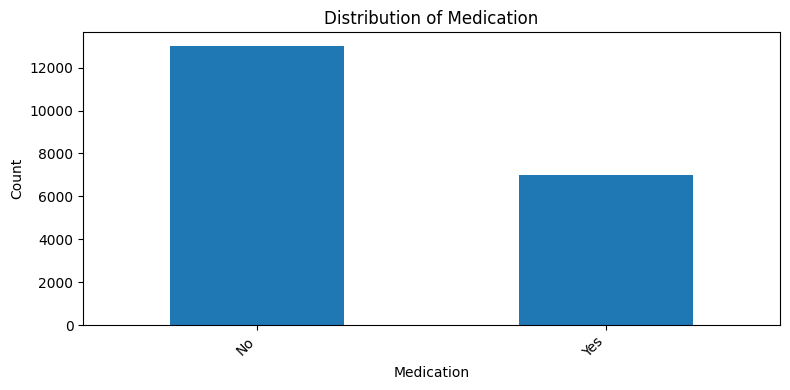

In [12]:
plot_categories = [
    col for col in [
        "Gender", "Smoking", "Alcohol", "Physical_Activity",
        "Family_History", "Diabetes", "Hypertension", "Resting_ECG",
        "Exercise_Angina", "Chest_Pain_Type", "Medication"
    ]
    if col in data.columns
]

for col in plot_categories:
    counts = data[col].value_counts(dropna=False)
    plt.figure(figsize=(8, 4))
    counts.plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## 14. Correlation analysis

Pearson correlation is calculated for numeric variables. Correlation does not establish causation, but it can reveal linear relationships and potential redundancy between numerical features.

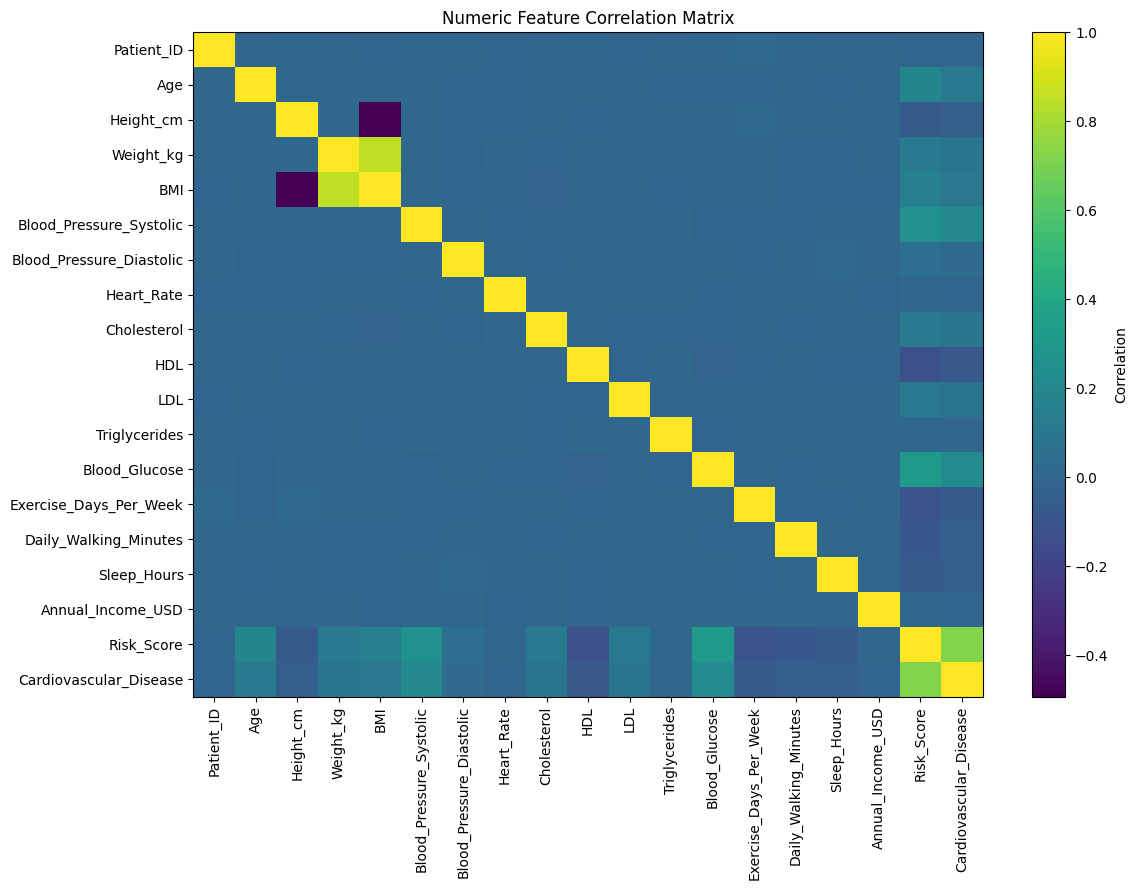

In [13]:
corr = data[numeric_columns].corr(numeric_only=True)

plt.figure(figsize=(12, 9))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Numeric Feature Correlation Matrix")
plt.tight_layout()
plt.show()


## 15. Strongest numeric correlations with the target

This analysis ranks numeric variables by the absolute magnitude of their correlation with the target. These values are descriptive associations rather than medical or causal conclusions.

In [14]:
if pd.api.types.is_numeric_dtype(data[TARGET]):
    target_corr = corr[TARGET].drop(TARGET).sort_values(key=lambda s: s.abs(), ascending=False)
    display(target_corr.to_frame("correlation_with_target"))
else:
    print("Target is not numeric, so numeric Pearson correlation with the target is skipped.")


,correlation_with_target
Risk_Score,0.724
Blood_Glucose,0.226
Blood_Pressure_Systolic,0.208
Age,0.123
BMI,0.104
Weight_kg,0.090
Cholesterol,0.089
LDL,0.082
HDL,-0.078
Exercise_Days_Per_Week,-0.065


## 16. Target rate by categorical feature

For categorical variables, we calculate the observed percentage of positive target cases in each category. This is useful for exploratory comparison while avoiding claims that a category itself causes disease.

In [15]:
cat_target_tables = {}

for col in categorical_columns:
    if col == TARGET:
        continue
    if data[col].nunique(dropna=False) <= 20:
        rate = data.groupby(col, dropna=False)[TARGET].agg(["count", "mean"])
        rate["target_rate_percent"] = rate["mean"] * 100
        rate = rate.drop(columns="mean").sort_values("target_rate_percent", ascending=False)
        cat_target_tables[col] = rate
        print(f"\n--- {col} ---")
        display(rate)



--- Gender ---


,count,target_rate_percent
Gender,,
Female,10445,30.627
Male,9555,30.570



--- Diabetes ---


,count,target_rate_percent
Diabetes,,
Yes,6088,51.101
No,13912,21.629



--- Hypertension ---


...

,count,target_rate_percent
Region,,
Central,4030,31.017
East,4001,30.867
North,3998,30.440
South,3966,30.383
West,4005,30.287



--- Education_Level ---


,count,target_rate_percent
Education_Level,,
PhD,1023,31.672
High School,7041,30.819
Bachelor,7947,30.502
Master,3989,30.133



--- BMI_Category ---


,count,target_rate_percent
BMI_Category,,
Obese,4788,41.458
Overweight,5886,27.778
Underweight,2224,27.428
Normal,7102,26.612


## 17. Target rate by binned numeric features

Binning selected numeric variables makes it easier to compare target prevalence across ranges rather than individual numerical values.

In [16]:
bin_candidates = [
    col for col in ["Age", "BMI", "Cholesterol", "Resting_BP", "Max_Heart_Rate", "ST_Depression"]
    if col in data.columns
]

for col in bin_candidates:
    temp = data[[col, TARGET]].dropna().copy()
    if temp[col].nunique() >= 5:
        temp["bin"] = pd.qcut(temp[col], q=5, duplicates="drop")
        summary = temp.groupby("bin", observed=False)[TARGET].agg(["count", "mean"])
        summary["target_rate_percent"] = summary["mean"] * 100
        print(f"\n--- {col} ---")
        display(summary.drop(columns="mean"))



--- Age ---


,count,target_rate_percent
bin,,
"(19.999, 33.0]",4182,25.179
"(33.0, 46.0]",4039,25.328
"(46.0, 59.0]",3879,25.728
"(59.0, 72.0]",3939,38.385
"(72.0, 85.0]",3961,38.728



--- BMI ---


,count,target_rate_percent
bin,,
"(10.199, 20.5]",3912,27.224
"(20.5, 23.9]",3903,27.082
"(23.9, 27.0]",3826,26.712
"(27.0, 30.9]",3939,30.388
"(30.9, 56.5]",3820,41.832



--- Cholesterol ---


,count,target_rate_percent
bin,,
"(119.999, 170.0]",4005,28.240
"(170.0, 194.0]",4022,27.747
"(194.0, 215.0]",4057,26.547
"(215.0, 239.0]",3998,28.014
"(239.0, 350.0]",3918,42.777


## 18. Outlier screening with the IQR rule

The IQR rule identifies observations below Q1 − 1.5×IQR or above Q3 + 1.5×IQR. These are statistical flags, not automatic errors, so they should be interpreted in context.

In [17]:
outlier_rows = []

for col in numeric_columns:
    if col == TARGET:
        continue
    series = data[col].dropna()
    if series.empty:
        continue
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0:
        count = 0
    else:
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        count = ((series < lower) | (series > upper)).sum()
    outlier_rows.append([col, q1, q3, iqr, count, count / len(series) * 100])

outlier_summary = pd.DataFrame(
    outlier_rows,
    columns=["feature", "Q1", "Q3", "IQR", "outlier_count", "outlier_percent"]
).sort_values("outlier_count", ascending=False)

display(outlier_summary)


,feature,Q1,Q3,IQR,outlier_count,outlier_percent
7,Heart_Rate,68.000,81.000,13.000,210,1.050
4,BMI,21.500,29.800,8.300,164,0.845
17,Risk_Score,6.860,12.590,5.730,118,0.590
11,Triglycerides,109.000,190.000,81.000,77,0.397
9,HDL,44.000,64.000,20.000,71,0.366
5,Blood_Pressure_Systolic,113.000,137.000,24.000,64,0.320
10,LDL,96.000,143.000,47.000,61,0.314
3,Weight_kg,61.900,82.300,20.400,60,0.300
2,Height_cm,161.200,174.800,13.600,55,0.275
12,Blood_Glucose,84.000,125.000,41.000,50,0.258


## 19. Prepare features and target

The identifier column, when present, is removed from the modeling matrix because it represents record identity rather than a meaningful predictive attribute. The target is separated from the predictors.

In [18]:
model_data = data.copy()

id_candidates = [
    col for col in model_data.columns
    if col.lower() in {"patient_id", "id", "record_id"}
]

ID_COLUMNS = id_candidates
FEATURES = [col for col in model_data.columns if col not in ID_COLUMNS + [TARGET]]

X = model_data[FEATURES].copy()
y = model_data[TARGET].copy()

print("Identifier columns removed:", ID_COLUMNS if ID_COLUMNS else "None")
print("Feature count:", X.shape[1])
print("Target count:", y.shape[0])
display(X.head())


Identifier columns removed: ['Patient_ID']
Feature count: 33
Target count: 20000


,Age,Gender,Height_cm,Weight_kg,BMI,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Heart_Rate,Cholesterol,HDL,LDL,Triglycerides,Blood_Glucose,Diabetes,Hypertension,Smoking,Alcohol_Consumption,Physical_Activity,Exercise_Days_Per_Week,Daily_Walking_Minutes,Sleep_Hours,Stress_Level,Family_History,Chest_Pain,Shortness_of_Breath,ECG_Result,Medication,Diet_Quality,Annual_Income_USD,Region,Education_Level,BMI_Category,Risk_Score
0,41,Female,165.600,89.000,32.500,118,79,85,248,44.000,NaN,255.000,93.000,No,No,Yes,No,Moderate,7,56,8.500,High,No,No,No,Normal,No,Average,109870,Central,Bachelor,Obese,7.630
1,43,Female,163.100,40.000,15.000,114,55,73,219,58.000,96.000,176.000,75.000,No,No,No,No,Moderate,2,42,7.000,Low,No,No,Yes,Normal,No,Poor,33025,North,Master,Underweight,2.960
2,37,Female,154.000,96.200,40.600,127,74,68,219,23.000,107.000,231.000,118.000,No,No,Yes,Yes,Low,5,82,7.700,Moderate,No,No,No,Normal,No,Poor,53705,South,Bachelor,Obese,9.730
3,81,Female,168.700,72.800,25.600,137,87,70,154,49.000,102.000,207.000,NaN,Yes,No,Yes,No,Moderate,4,111,8.000,Moderate,Yes,Yes,Yes,Normal,Yes,Average,172645,West,Bachelor,Overweight,15.810
4,32,Female,176.700,53.100,17.000,144,79,66,225,58.000,96.000,136.000,121.000,No,Yes,Yes,No,Moderate,5,56,6.500,Moderate,Yes,No,No,Normal,Yes,Average,93228,West,High School,Underweight,9.400


## 20. Train-test split

A stratified split preserves the target class proportions in both training and testing sets. The test set is held back until final evaluation.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True).sort_index().mul(100).to_frame("percent"))

print("Testing target distribution:")
display(y_test.value_counts(normalize=True).sort_index().mul(100).to_frame("percent"))


Training shape: (16000, 33)
Testing shape: (4000, 33)

Training target distribution:


,percent
Cardiovascular_Disease,
0,69.400
1,30.600


Testing target distribution:


,percent
Cardiovascular_Disease,
0,69.400
1,30.600


## 21. Build the preprocessing pipeline

Numeric features are median-imputed and standardized. Categorical features are most-frequent imputed and one-hot encoded. `ColumnTransformer` keeps preprocessing consistent between training and testing data.

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))


Numeric features: 17
Categorical features: 16


## 22. Baseline Logistic Regression model

Logistic Regression provides a strong and interpretable baseline for binary classification. The model is placed inside a pipeline so all preprocessing is learned only from the training data.

In [21]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

logistic_model.fit(X_train, y_train)
logistic_pred = logistic_model.predict(X_test)

print("Logistic Regression trained successfully.")


Logistic Regression trained successfully.


## 23. Evaluate the Logistic Regression baseline

Accuracy alone can hide class-specific weaknesses. We therefore report accuracy, precision, recall, F1-score, ROC-AUC, and a confusion matrix.

,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
Logistic Regression,0.954,0.951,0.895,0.922,0.951


              precision    recall  f1-score   support

           0       0.95      0.98      0.97      2776
           1       0.95      0.89      0.92      1224

    accuracy                           0.95      4000
   macro avg       0.95      0.94      0.94      4000
weighted avg       0.95      0.95      0.95      4000



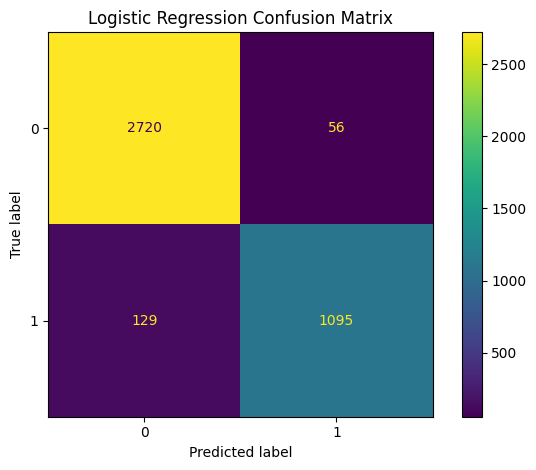

In [22]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

def evaluate_model(name, model, X_eval, y_eval):
    pred = model.predict(X_eval)
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_eval)[:, 1]
    else:
        proba = None

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, pred),
        "Precision": precision_score(y_eval, pred, zero_division=0),
        "Recall": recall_score(y_eval, pred, zero_division=0),
        "F1": f1_score(y_eval, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_eval, proba) if proba is not None else np.nan
    }
    return metrics, pred, proba

logistic_metrics, logistic_pred, logistic_proba = evaluate_model(
    "Logistic Regression", logistic_model, X_test, y_test
)

display(pd.DataFrame([logistic_metrics]).set_index("Model"))

print(classification_report(y_test, logistic_pred, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test, logistic_pred)
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()


## 24. Random Forest model

Random Forest captures nonlinear relationships and interactions that a linear model may not capture. The preprocessing pipeline is reused so the comparison remains consistent.

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=400,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)
rf_metrics, rf_pred, rf_proba = evaluate_model(
    "Random Forest", rf_model, X_test, y_test
)

display(pd.DataFrame([rf_metrics]).set_index("Model"))


,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
Random Forest,0.966,0.967,0.920,0.943,0.954


## 25. Extra Trees model

Extra Trees is another tree-ensemble method that introduces additional randomization when selecting split thresholds. It provides a second nonlinear benchmark.

In [24]:
from sklearn.ensemble import ExtraTreesClassifier

extra_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ExtraTreesClassifier(
        n_estimators=400,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

extra_model.fit(X_train, y_train)
extra_metrics, extra_pred, extra_proba = evaluate_model(
    "Extra Trees", extra_model, X_test, y_test
)

display(pd.DataFrame([extra_metrics]).set_index("Model"))


,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
Extra Trees,0.897,0.902,0.746,0.817,0.938


## 26. HistGradientBoosting model

HistGradientBoosting provides a gradient-boosted tree benchmark. Because the preprocessing pipeline produces a dense matrix, it can be used directly here.

In [25]:
from sklearn.ensemble import HistGradientBoostingClassifier

hist_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingClassifier(
        max_iter=250,
        learning_rate=0.08,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE
    ))
])

hist_model.fit(X_train, y_train)
hist_metrics, hist_pred, hist_proba = evaluate_model(
    "HistGradientBoosting", hist_model, X_test, y_test
)

display(pd.DataFrame([hist_metrics]).set_index("Model"))


,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
HistGradientBoosting,0.965,0.967,0.916,0.941,0.952


## 27. Compare all baseline models

The models are compared using multiple classification metrics. The table is a factual performance summary on the same held-out test set; it is not a universal ranking of algorithms.

In [26]:
results = pd.DataFrame([
    logistic_metrics,
    rf_metrics,
    extra_metrics,
    hist_metrics
]).set_index("Model")

display(results.sort_values("ROC_AUC", ascending=False).round(4))


,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
Random Forest,0.966,0.967,0.920,0.943,0.954
HistGradientBoosting,0.965,0.967,0.916,0.941,0.952
Logistic Regression,0.954,0.951,0.895,0.922,0.951
Extra Trees,0.897,0.902,0.746,0.817,0.938


## 28. Cross-validation on the training data

Cross-validation provides a more stable estimate of training-set performance than relying on one split. The held-out test set remains untouched for the final evaluation.

In [27]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidate_models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model,
    "Extra Trees": extra_model,
    "HistGradientBoosting": hist_model
}

cv_rows = []

for name, model in candidate_models.items():
    scores = cross_validate(
        model, X_train, y_train,
        cv=cv,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
        n_jobs=-1
    )
    cv_rows.append({
        "Model": name,
        "CV Accuracy Mean": scores["test_accuracy"].mean(),
        "CV Accuracy Std": scores["test_accuracy"].std(),
        "CV F1 Mean": scores["test_f1"].mean(),
        "CV ROC-AUC Mean": scores["test_roc_auc"].mean()
    })

cv_results = pd.DataFrame(cv_rows).set_index("Model")
display(cv_results.round(4))


,CV Accuracy Mean,CV Accuracy Std,CV F1 Mean,CV ROC-AUC Mean
Model,,,,
Logistic Regression,0.961,0.003,0.935,0.960
Random Forest,0.971,0.002,0.952,0.961
Extra Trees,0.905,0.003,0.833,0.945
HistGradientBoosting,0.970,0.001,0.950,0.961


## 29. Hyperparameter tuning for Random Forest

Randomized search explores a range of Random Forest configurations using cross-validation. The search is performed only on the training set to avoid test-set leakage.

In [28]:
from sklearn.model_selection import RandomizedSearchCV

rf_search_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

rf_params = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 8, 12, 18, 24],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    rf_search_pipeline,
    param_distributions=rf_params,
    n_iter=12,
    scoring="roc_auc",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("Best CV ROC-AUC:", round(rf_search.best_score_, 4))
print("Best parameters:")
for k, v in rf_search.best_params_.items():
    print(f"  {k}: {v}")


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best CV ROC-AUC: 0.9624
Best parameters:
  model__n_estimators: 300
  model__min_samples_split: 10
  model__min_samples_leaf: 2
  model__max_features: None
  model__max_depth: None


## 30. Evaluate the tuned Random Forest

The tuned model is evaluated once on the untouched test set. This gives a direct comparison with the earlier baseline models.

In [29]:
tuned_rf = rf_search.best_estimator_

tuned_rf_metrics, tuned_rf_pred, tuned_rf_proba = evaluate_model(
    "Tuned Random Forest", tuned_rf, X_test, y_test
)

final_results = pd.concat([
    results,
    pd.DataFrame([tuned_rf_metrics]).set_index("Model")
])

display(final_results.sort_values("ROC_AUC", ascending=False).round(4))

print("\nClassification report for tuned Random Forest:")
print(classification_report(y_test, tuned_rf_pred, zero_division=0))


,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
Random Forest,0.966,0.967,0.920,0.943,0.954
Tuned Random Forest,0.966,0.967,0.920,0.943,0.953
HistGradientBoosting,0.965,0.967,0.916,0.941,0.952
Logistic Regression,0.954,0.951,0.895,0.922,0.951
Extra Trees,0.897,0.902,0.746,0.817,0.938



Classification report for tuned Random Forest:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      2776
           1       0.97      0.92      0.94      1224

    accuracy                           0.97      4000
   macro avg       0.97      0.95      0.96      4000
weighted avg       0.97      0.97      0.97      4000



## 31. ROC curves for model comparison

ROC curves visualize the trade-off between true-positive and false-positive rates across classification thresholds. AUC summarizes this curve into a single threshold-independent measure.

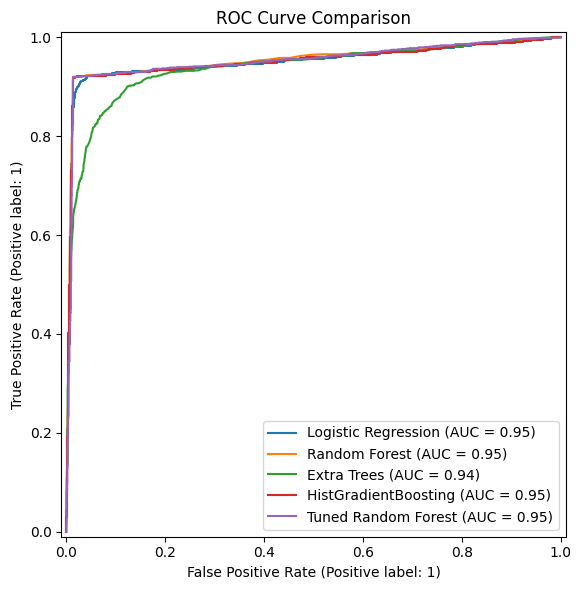

In [30]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8, 6))

for name, model in {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model,
    "Extra Trees": extra_model,
    "HistGradientBoosting": hist_model,
    "Tuned Random Forest": tuned_rf
}.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=plt.gca())

plt.title("ROC Curve Comparison")
plt.tight_layout()
plt.show()


## 32. Precision-recall curves

Precision-recall curves are particularly useful when positive and negative classes are not perfectly balanced. They show how precision changes as recall changes across thresholds.

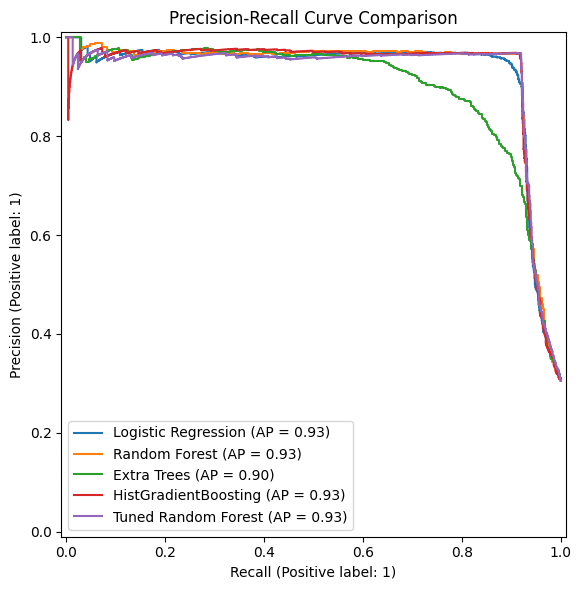

In [31]:
from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(8, 6))

for name, model in {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model,
    "Extra Trees": extra_model,
    "HistGradientBoosting": hist_model,
    "Tuned Random Forest": tuned_rf
}.items():
    PrecisionRecallDisplay.from_estimator(
        model, X_test, y_test, name=name, ax=plt.gca()
    )

plt.title("Precision-Recall Curve Comparison")
plt.tight_layout()
plt.show()


## 33. Permutation feature importance

Permutation importance measures how much model performance changes when a feature's values are randomly shuffled. This is model-specific and should be interpreted as predictive importance, not causal importance.

,feature,importance_mean,importance_std
32,Risk_Score,0.381,0.008
11,Triglycerides,0.002,0.001
20,Sleep_Hours,0.001,0.001
10,LDL,0.001,0.001
5,Blood_Pressure_Systolic,0.001,0.001
2,Height_cm,0.001,0.001
4,BMI,0.000,0.000
13,Diabetes,0.000,0.000
14,Hypertension,0.000,0.000
22,Family_History,0.000,0.000


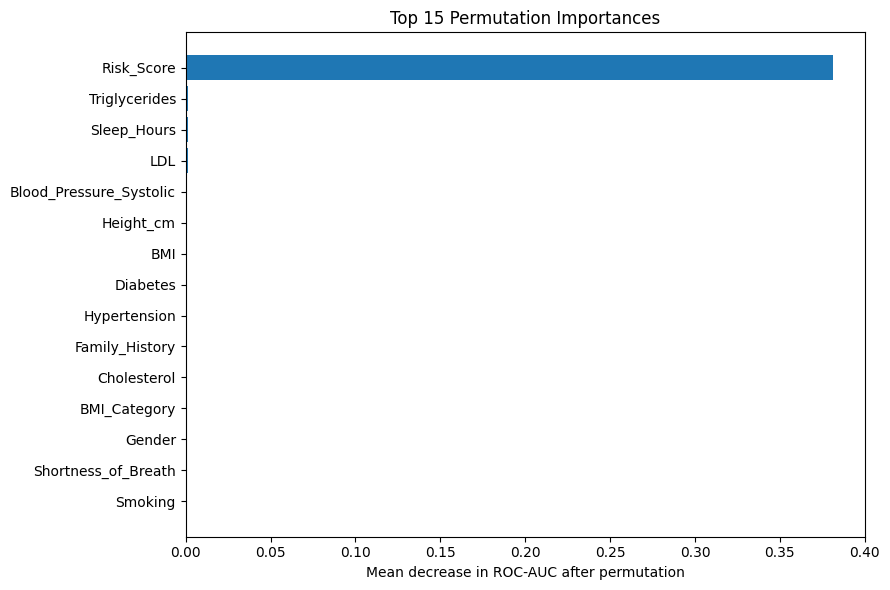

In [32]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    tuned_rf,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(importance.head(20))

plt.figure(figsize=(9, 6))
top_imp = importance.head(15).sort_values("importance_mean")
plt.barh(top_imp["feature"], top_imp["importance_mean"])
plt.xlabel("Mean decrease in ROC-AUC after permutation")
plt.title("Top 15 Permutation Importances")
plt.tight_layout()
plt.show()


## 34. Calibration and probability quality

For risk-oriented classification tasks, predicted probabilities can be informative in addition to hard class labels. This section evaluates the Brier score and plots a calibration curve for the tuned model.

Tuned Random Forest Brier score: 0.0343


<Figure size 700x600 with 0 Axes>

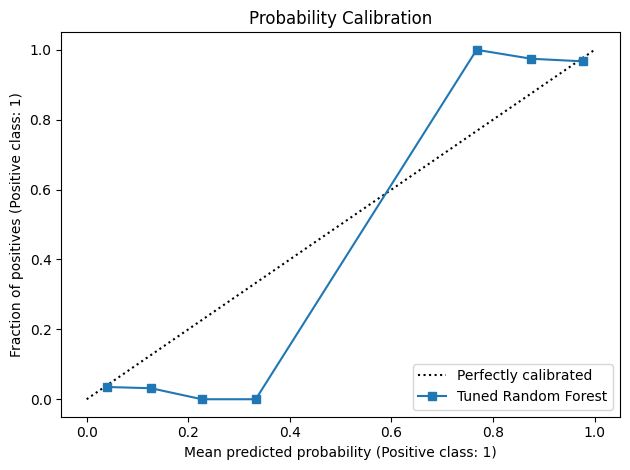

In [33]:
from sklearn.metrics import brier_score_loss
from sklearn.calibration import CalibrationDisplay

brier = brier_score_loss(y_test, tuned_rf_proba)
print(f"Tuned Random Forest Brier score: {brier:.4f}")

plt.figure(figsize=(7, 6))
CalibrationDisplay.from_predictions(
    y_test,
    tuned_rf_proba,
    n_bins=10,
    name="Tuned Random Forest"
)
plt.title("Probability Calibration")
plt.tight_layout()
plt.show()


## 35. Final model summary and reproducibility information

The final section records the dataset dimensions, target distribution, test-set metrics, and selected model configuration. The results are intended for reproducible machine learning analysis rather than clinical decision-making.

In [34]:
best_row = final_results.sort_values("ROC_AUC", ascending=False).iloc[0]

print("=" * 70)
print("FINAL NOTEBOOK SUMMARY")
print("=" * 70)
print(f"Dataset rows: {data.shape[0]:,}")
print(f"Dataset columns: {data.shape[1]:,}")
print(f"Target: {TARGET}")
print(f"Positive-class rate: {y.mean() * 100:.2f}%")
print(f"Training rows: {len(X_train):,}")
print(f"Testing rows: {len(X_test):,}")

print("\nTest-set metrics for Tuned Random Forest:")
for metric in ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]:
    print(f"{metric:10s}: {tuned_rf_metrics[metric]:.4f}")

print("\nTop predictive features by permutation importance:")
display(importance.head(10))

print("\nImportant interpretation note:")
print("These results describe performance on a synthetic dataset and should not be")
print("interpreted as evidence of clinical effectiveness or used for medical diagnosis.")


FINAL NOTEBOOK SUMMARY
Dataset rows: 20,000
Dataset columns: 35
Target: Cardiovascular_Disease
Positive-class rate: 30.60%
Training rows: 16,000
Testing rows: 4,000

Test-set metrics for Tuned Random Forest:
Accuracy  : 0.9660
Precision : 0.9674
Recall    : 0.9199
F1        : 0.9430
ROC_AUC   : 0.9529

Top predictive features by permutation importance:


,feature,importance_mean,importance_std
32,Risk_Score,0.381,0.008
11,Triglycerides,0.002,0.001
20,Sleep_Hours,0.001,0.001
10,LDL,0.001,0.001
5,Blood_Pressure_Systolic,0.001,0.001
2,Height_cm,0.001,0.001
4,BMI,0.000,0.000
13,Diabetes,0.000,0.000
14,Hypertension,0.000,0.000
22,Family_History,0.000,0.000



Important interpretation note:
These results describe performance on a synthetic dataset and should not be
interpreted as evidence of clinical effectiveness or used for medical diagnosis.
